In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))

from src.utils.helpers import load_pickle
from src.explainers.shap_explainer import create_explainer, explain_instance

c:\Users\anderson\Downloads\GIT\demand-forecast-xai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Configure experiment

random_state = 42

  
store_filter = ['CA_1', 'TX_1']

if isinstance(store_filter, (list, tuple, set, pd.Index)):
    store_suffix = '_'.join(map(str, store_filter))
else:
    store_suffix = store_filter if store_filter else 'all_stores'

artifact_dir = Path('../experiments/exp_001_lgbm/artifacts')

model_path = artifact_dir / f'lightgbm_{store_suffix}.pkl'
x_test_path = artifact_dir / f'X_test_predict_{store_suffix}.parquet'

sample_path = artifact_dir / f'sample_{store_suffix}.parquet'

In [5]:
# Load artifacts

model = load_pickle(model_path)
X_test = pd.read_parquet(x_test_path)

selected_predictions = pd.read_parquet(sample_path)

Loaded from ..\experiments\exp_001_lgbm\artifacts\lightgbm_CA_1_TX_1.pkl


In [6]:
# Create SHAP explainer

explainer = create_explainer(model)

In [7]:
# Iterate over selected instances and explain each one

all_explanations = []

for row in selected_predictions.itertuples(index=False):
    instance_id = int(row.instance_id)
    instance = X_test.loc[[instance_id]].copy()

    explanation = explain_instance(
        explainer=explainer,
        instance=instance,
        instance_id=instance_id
    )

    all_explanations.append(explanation)

shap_explanations = pd.concat(all_explanations, ignore_index=True) if all_explanations else pd.DataFrame(columns=['instance_id', 'feature', 'feature_value', 'importance'])

In [8]:
# Inspect explanations

shap_explanations.head()

,instance_id,feature,feature_value,importance
0,25407,cat_id,FOODS,0.000058
1,25407,dept_id,FOODS_2,0.002443
2,25407,item_id,FOODS_2_293,-0.002931
3,25407,state_id,TX,-0.003349
4,25407,store_id,TX_1,-0.001176


In [9]:
# Save
shap_output_path = artifact_dir / f'shap_explanation_{store_suffix}.parquet'

shap_explanations.to_parquet(
    shap_output_path,
    index=False
)

print(f'SHAP explanations saved to: {shap_output_path}')

SHAP explanations saved to: ..\experiments\exp_001_lgbm\artifacts\shap_explanation_CA_1_TX_1.parquet


# Analysis

In [21]:
import matplotlib.pyplot as plt
import numpy as np

shap_explanations = pd.read_parquet(shap_output_path)

shap_explanations['abs_importance'] = shap_explanations['importance'].abs()

print(shap_explanations.shape)
print(shap_explanations['instance_id'].nunique())
print(shap_explanations['feature'].nunique())

shap_explanations.head()

(4400, 5)
200
22


,instance_id,feature,feature_value,importance,abs_importance
0,25407,cat_id,FOODS,0.000058,0.000058
1,25407,dept_id,FOODS_2,0.002443,0.002443
2,25407,item_id,FOODS_2_293,-0.002931,0.002931
3,25407,state_id,TX,-0.003349,0.003349
4,25407,store_id,TX_1,-0.001176,0.001176


In [11]:
global_importance = (
    shap_explanations
    .groupby('feature', as_index=False)
    .agg(
        mean_abs_shap=('abs_importance', 'mean'),
        mean_shap=('importance', 'mean')
    )
    .sort_values('mean_abs_shap', ascending=False)
)

global_importance.head(15)

,feature,mean_abs_shap,mean_shap
13,rolling_mean_7,6.903594,6.749423
11,rolling_mean_28,1.498063,1.492251
2,day_of_week,0.993901,0.442232
9,item_id,0.908013,0.851845
12,rolling_mean_28_sales_lag_28,0.168526,0.146604
15,sales_lag_28,0.127307,0.088493
8,is_snap,0.114829,0.009910
16,sales_lag_7,0.084558,-0.078132
1,day_of_month,0.058724,0.013850
17,sell_price,0.052687,0.031687


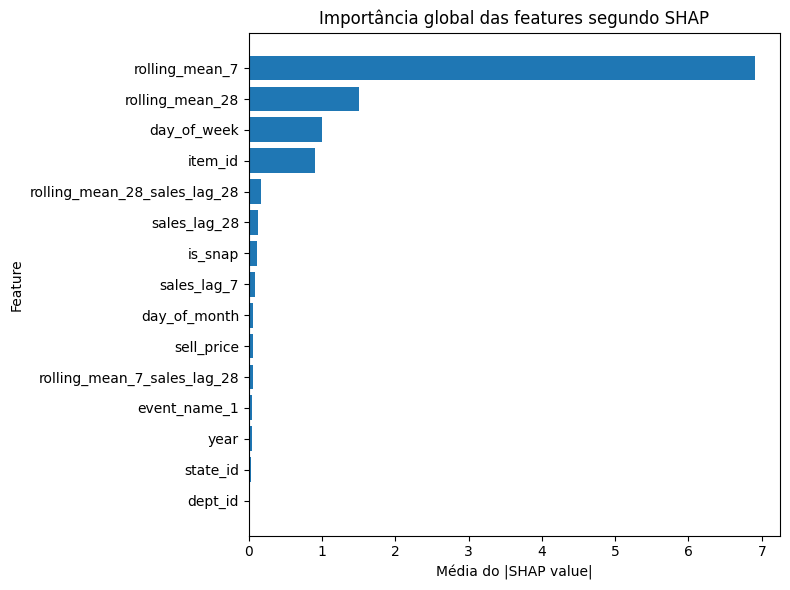

In [12]:
top_n = 15

plot_data = (
    global_importance
    .head(top_n)
    .sort_values('mean_abs_shap')
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_data['feature'],
    plot_data['mean_abs_shap']
)

plt.xlabel('Média do |SHAP value|')
plt.ylabel('Feature')
plt.title('Importância global das features segundo SHAP')

plt.tight_layout()
plt.show()

In [13]:
feature_direction = (
    shap_explanations
    .groupby('feature')
    .agg(
        mean_abs_shap=('abs_importance', 'mean'),
        mean_shap=('importance', 'mean'),
        positive_pct=('importance', lambda x: (x > 0).mean()),
        negative_pct=('importance', lambda x: (x < 0).mean())
    )
    .sort_values('mean_abs_shap', ascending=False)
)

feature_direction.head(15)

,mean_abs_shap,mean_shap,positive_pct,negative_pct
feature,,,,
rolling_mean_7,6.903594,6.749423,0.595,0.405
rolling_mean_28,1.498063,1.492251,0.930,0.070
day_of_week,0.993901,0.442232,0.450,0.550
item_id,0.908013,0.851845,0.455,0.545
rolling_mean_28_sales_lag_28,0.168526,0.146604,0.725,0.275
sales_lag_28,0.127307,0.088493,0.310,0.690
is_snap,0.114829,0.009910,0.330,0.670
sales_lag_7,0.084558,-0.078132,0.490,0.510
day_of_month,0.058724,0.013850,0.250,0.750


In [14]:
sample_path = artifact_dir / f'sample_{store_suffix}.parquet'

sample = pd.read_parquet(sample_path)

shap_analysis = shap_explanations.merge(
    sample,
    on='instance_id',
    how='left'
)

shap_analysis.head()

,instance_id,feature,feature_value,importance,abs_importance,id,date,y_true,y_pred,error,absolute_error,error_direction,prediction_quality
0,25407,cat_id,FOODS,0.000058,0.000058,FOODS_2_293_TX_1,2016-04-29,1,0.998,-0.002,0.002,under,good
1,25407,dept_id,FOODS_2,0.002443,0.002443,FOODS_2_293_TX_1,2016-04-29,1,0.998,-0.002,0.002,under,good
2,25407,item_id,FOODS_2_293,-0.002931,0.002931,FOODS_2_293_TX_1,2016-04-29,1,0.998,-0.002,0.002,under,good
3,25407,state_id,TX,-0.003349,0.003349,FOODS_2_293_TX_1,2016-04-29,1,0.998,-0.002,0.002,under,good
4,25407,store_id,TX_1,-0.001176,0.001176,FOODS_2_293_TX_1,2016-04-29,1,0.998,-0.002,0.002,under,good


In [16]:
quality_importance = (
    shap_analysis
    .groupby(['prediction_quality', 'feature'], as_index=False)
    .agg(
        mean_abs_shap=('abs_importance', 'mean'),
        mean_shap=('importance', 'mean')
    )
)

quality_importance['rank'] = (
    quality_importance
    .groupby('prediction_quality')['mean_abs_shap']
    .rank(ascending=False, method='min')
)

quality_importance.sort_values(
    ['prediction_quality', 'rank']
).head(30)

,prediction_quality,feature,mean_abs_shap,mean_shap,rank
13,bad,rolling_mean_7,13.468249,13.449814,1.0
11,bad,rolling_mean_28,2.770036,2.764597,2.0
2,bad,day_of_week,1.825375,0.859672,3.0
9,bad,item_id,1.768077,1.727381,4.0
12,bad,rolling_mean_28_sales_lag_28,0.282588,0.272660,5.0
15,bad,sales_lag_28,0.245294,0.180827,6.0
8,bad,is_snap,0.198619,0.023136,7.0
16,bad,sales_lag_7,0.163556,-0.159333,8.0
1,bad,day_of_month,0.109156,0.026668,9.0
14,bad,rolling_mean_7_sales_lag_28,0.094597,-0.061592,10.0


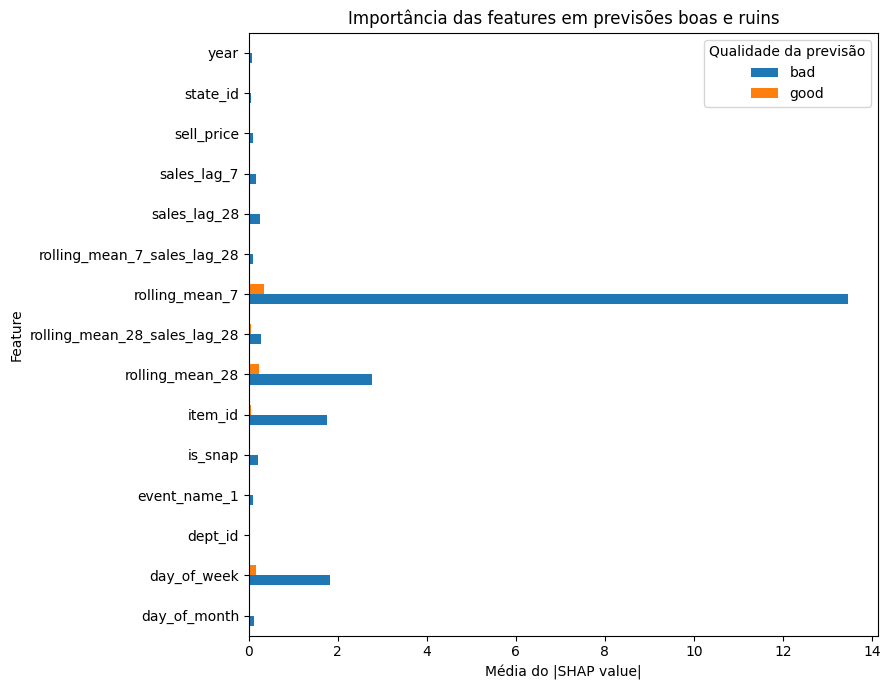

In [17]:
top_features = (
    global_importance
    .head(15)['feature']
)

plot_data = (
    quality_importance[
        quality_importance['feature'].isin(top_features)
    ]
    .pivot(
        index='feature',
        columns='prediction_quality',
        values='mean_abs_shap'
    )
)

plot_data.plot(
    kind='barh',
    figsize=(9, 7)
)

plt.xlabel('Média do |SHAP value|')
plt.ylabel('Feature')
plt.title('Importância das features em previsões boas e ruins')
plt.legend(title='Qualidade da previsão')

plt.tight_layout()
plt.show()

In [18]:
comparison = (
    quality_importance
    .pivot(
        index='feature',
        columns='prediction_quality',
        values='mean_abs_shap'
    )
    .reset_index()
)

comparison.head()

prediction_quality,feature,bad,good
0,cat_id,0.004144,0.000496
1,day_of_month,0.109156,0.008292
2,day_of_week,1.825375,0.162427
3,dept_id,0.032277,0.007158
4,event_name_1,0.087920,0.005881


In [22]:
comparison['difference'] = (
    comparison['bad'] - comparison['good']
)

comparison['ratio'] = (
    comparison['bad'] /
    comparison['good'].replace(0, np.nan)
)

comparison.sort_values(
    'difference',
    ascending=False
).head(15)

prediction_quality,feature,bad,good,difference,ratio
13,rolling_mean_7,13.468249,0.338939,13.129309,39.736470
11,rolling_mean_28,2.770036,0.226090,2.543946,12.251929
9,item_id,1.768077,0.047948,1.720129,36.874532
2,day_of_week,1.825375,0.162427,1.662948,11.238109
15,sales_lag_28,0.245294,0.009319,0.235975,26.321058
12,rolling_mean_28_sales_lag_28,0.282588,0.054464,0.228124,5.188519
8,is_snap,0.198619,0.031039,0.167580,6.398934
16,sales_lag_7,0.163556,0.005559,0.157997,29.420534
1,day_of_month,0.109156,0.008292,0.100864,13.164392
14,rolling_mean_7_sales_lag_28,0.094597,0.007708,0.086889,12.272193


In [23]:
instance_shap = (
    shap_analysis
    .groupby('instance_id', as_index=False)
    .agg(
        total_abs_shap=('abs_importance', 'sum'),
        mean_abs_shap=('abs_importance', 'mean')
    )
)

instance_error = (
    sample[
        ['instance_id', 'absolute_error', 'prediction_quality']
    ]
)

instance_analysis = instance_shap.merge(
    instance_error,
    on='instance_id'
)

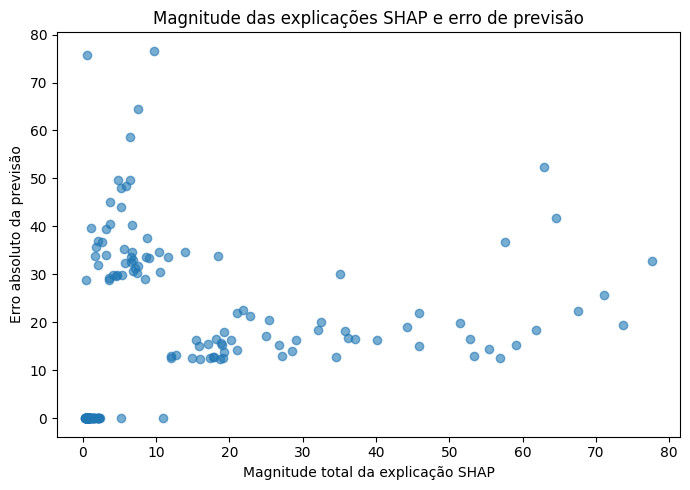

In [24]:
plt.figure(figsize=(7, 5))

plt.scatter(
    instance_analysis['total_abs_shap'],
    instance_analysis['absolute_error'],
    alpha=0.6
)

plt.xlabel('Magnitude total da explicação SHAP')
plt.ylabel('Erro absoluto da previsão')
plt.title('Magnitude das explicações SHAP e erro de previsão')

plt.tight_layout()
plt.show()

In [25]:
instance_analysis[
    ['total_abs_shap', 'absolute_error']
].corr(method='spearman')

,total_abs_shap,absolute_error
total_abs_shap,1.000000,0.632461
absolute_error,0.632461,1.000000


In [26]:
instance_id = sample.loc[
    sample['absolute_error'].idxmax(),
    'instance_id'
]

local_explanation = (
    shap_analysis[
        shap_analysis['instance_id'] == instance_id
    ]
    .sort_values('abs_importance', ascending=False)
)

local_explanation[
    ['feature', 'feature_value', 'importance']
].head(10)

,feature,feature_value,importance
768,rolling_mean_7,7.5196742123436575,4.764424
750,item_id,FOODS_3_295,1.518491
769,rolling_mean_28,7.176626868096098,1.478431
757,day_of_week,2,1.350278
762,is_snap,1,0.158372
751,state_id,TX,-0.132500
767,rolling_mean_28_sales_lag_28,7.1054688,0.110835
763,sell_price,0.7998047,0.036456
764,sales_lag_7,9.247779131095568,-0.030135
766,rolling_mean_7_sales_lag_28,7.0,-0.029796


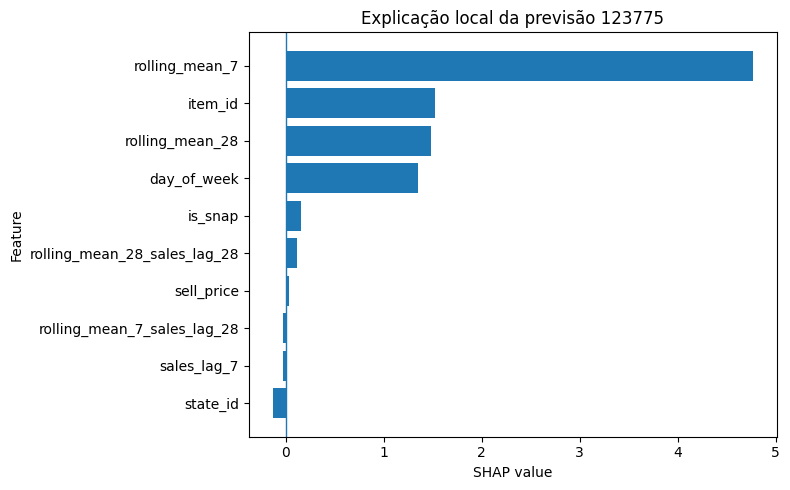

In [27]:
plot_data = (
    local_explanation
    .head(10)
    .sort_values('importance')
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data['feature'],
    plot_data['importance']
)

plt.axvline(0, linewidth=1)

plt.xlabel('SHAP value')
plt.ylabel('Feature')
plt.title(f'Explicação local da previsão {instance_id}')

plt.tight_layout()
plt.show()